In [9]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [10]:
data = """
Deep learning is a subset of machine learning.
Machine learning helps computers learn from data.
Artificial intelligence is transforming the world.
Neural networks are powerful models for learning patterns.
Text generation is an exciting application of deep learning.
"""

In [11]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([data])

total_words = len(tokenizer.word_index) + 1

print("Vocabulary Size:", total_words)
print(tokenizer.word_index)

Vocabulary Size: 30
{'learning': 1, 'is': 2, 'deep': 3, 'of': 4, 'machine': 5, 'a': 6, 'subset': 7, 'helps': 8, 'computers': 9, 'learn': 10, 'from': 11, 'data': 12, 'artificial': 13, 'intelligence': 14, 'transforming': 15, 'the': 16, 'world': 17, 'neural': 18, 'networks': 19, 'are': 20, 'powerful': 21, 'models': 22, 'for': 23, 'patterns': 24, 'text': 25, 'generation': 26, 'an': 27, 'exciting': 28, 'application': 29}


In [12]:
input_sequences = []

for line in data.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i+1]
        input_sequences.append(n_gram_sequence)

print(input_sequences[:5])

[[3, 1], [3, 1, 2], [3, 1, 2, 6], [3, 1, 2, 6, 7], [3, 1, 2, 6, 7, 4]]


In [13]:
max_sequence_len = max([len(seq) for seq in input_sequences])

input_sequences = np.array(
    pad_sequences(
        input_sequences,
        maxlen=max_sequence_len,
        padding='pre'
    )
)

print("Maximum Sequence Length:", max_sequence_len)

Maximum Sequence Length: 9


In [14]:
X = input_sequences[:, :-1]
y = input_sequences[:, -1]

y = tf.keras.utils.to_categorical(y, num_classes=total_words)

print("Input Shape:", X.shape)
print("Output Shape:", y.shape)

Input Shape: (33, 8)
Output Shape: (33, 30)


In [15]:
model = Sequential([
    Embedding(input_dim=total_words,
              output_dim=64),
    LSTM(128),
    Dense(64, activation='relu'),
    Dense(total_words, activation='softmax')
])

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
history = model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

Epoch 1/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.0000e+00 - loss: 3.4029  
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0909 - loss: 3.3965
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0606 - loss: 3.3935
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2121 - loss: 3.3902
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2727 - loss: 3.3865
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2424 - loss: 3.3814
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2424 - loss: 3.3755
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1818 - loss: 3.3687
Epoch 9/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1515 - loss: 3.3620
Epoch 10/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1515 - loss: 3.3545
Epoch 11/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1515 - loss: 3.3462
Epoch 12/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2121 - loss: 3.

In [17]:
def generate_text(seed_text, next_words):
    
    for _ in range(next_words):
        
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        
        token_list = pad_sequences(
            [token_list],
            maxlen=max_sequence_len-1,
            padding='pre'
        )
        
        predicted = np.argmax(
            model.predict(token_list, verbose=0),
            axis=-1
        )[0]

        output_word = ""

        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break

        seed_text += " " + output_word

    return seed_text

In [23]:
seed = "deep learning"

generated_text = generate_text(seed, 10)

print("Generated Text:")
print(generated_text)

Generated Text:
deep learning is a subset of machine learning learning patterns computers from


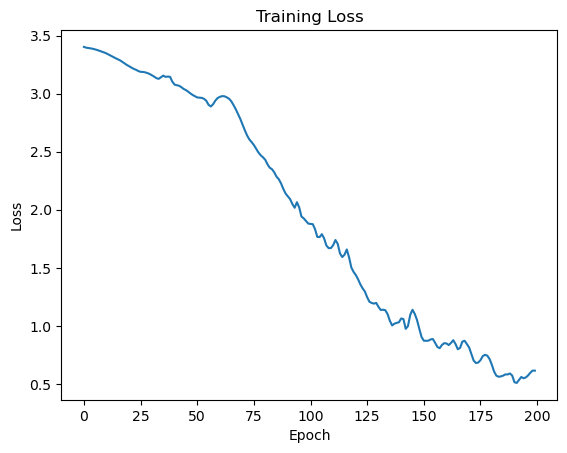

In [24]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

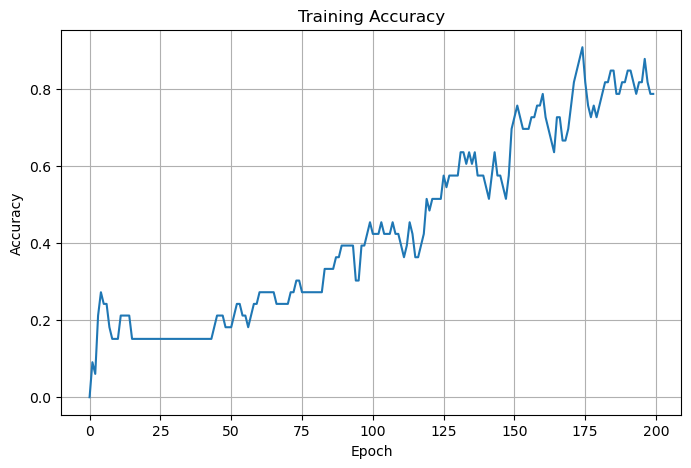

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'])
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()